In [21]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

In [22]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

In [23]:
print(X_train.shape)

(60000, 28, 28)


In [24]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [25]:
X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

In [26]:
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

In [27]:
model = keras.Sequential([

    keras.layers.Dense(128, activation='relu', input_shape=(784,)),

    keras.layers.Dense(64, activation='relu'),

    keras.layers.Dense(10, activation='softmax')
])

In [28]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [29]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9272 - loss: 0.2481 - val_accuracy: 0.9713 - val_loss: 0.1000
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9681 - loss: 0.1051 - val_accuracy: 0.9725 - val_loss: 0.0946
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9772 - loss: 0.0731 - val_accuracy: 0.9737 - val_loss: 0.0882
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9825 - loss: 0.0554 - val_accuracy: 0.9727 - val_loss: 0.0980
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9856 - loss: 0.0456 - val_accuracy: 0.9787 - val_loss: 0.0755
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9879 - loss: 0.0358 - val_accuracy: 0.9753 - val_loss: 0.0975
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9905 - loss: 0.0288 - val_accuracy: 0.9782 - val_loss: 0.0926
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9915 - loss: 0.0247

In [30]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9750 - loss: 0.0990
Test Accuracy: 0.9750000238418579


In [31]:
predictions = model.predict(X_test)

predicted_digit = np.argmax(predictions[0])

print("Predicted digit:", predicted_digit)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Predicted digit: 7


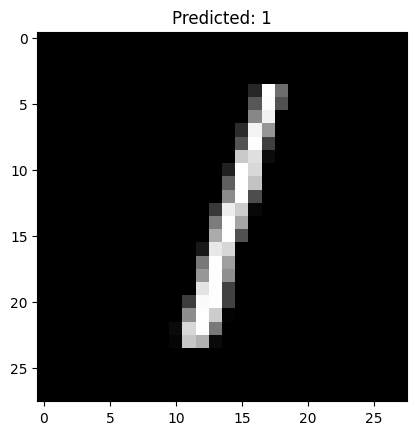

In [38]:
index = 2

predicted_digit = np.argmax(predictions[index])

plt.imshow(X_test[index].reshape(28,28), cmap="gray")
plt.title(f"Predicted: {predicted_digit}")
plt.show()